# GBS v2 - Evento: Ativo → Inativo
## Case Declínio de SKU - Grupo Boticário

**Evento:** `des_status_atual_agrup == 'Inativo'`

**Features:** Selecionadas por significância estatística (Kruskal-Wallis) + insights EDA

**Previsão:** P(inativar próx 25 ciclos | vivo hoje) = 1 - S(t+25)/S(t)

**Autor:** Gustavo

---
## 1. Setup

In [19]:
!pip install scikit-survival -q

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os, warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.inspection import permutation_importance

from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.nonparametric import kaplan_meier_estimator

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

FIGURES_DIR = '/content/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
HORIZONTE = 25
print('Bibliotecas carregadas!')

Bibliotecas carregadas!


---
## 2. Dados

In [22]:
from google.colab import drive
drive.mount('/content/drive')
#
# # Ajuste o caminho abaixo conforme a localização do arquivo no seu Drive
filepath = "/content/drive/MyDrive/Case SKU/data/base-de-dados.csv"
df = pd.read_csv(filepath, thousands=".")
print(f"Dados carregados com sucesso: {df.shape[0]} linhas x {df.shape[1]} colunas")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dados carregados com sucesso: 126781 linhas x 22 colunas


In [23]:
cols_object = df.select_dtypes(include=['object']).columns.tolist()
cols_excluir = ['sk_produto_case','cod_canal_portfolio','des_categoria_portfolio','des_status_atual_agrup']
for col in cols_object:
    if col not in cols_excluir:
        amostra = df[col].dropna().head(100).astype(str)
        if amostra.str.match(r'^[\d\s\.\,\-\+R\$%]+$').mean() > 0.7:
            serie = df[col].astype(str).str.strip().str.replace('.','',regex=False).str.replace(',','.',regex=False)
            df[col] = pd.to_numeric(serie, errors='coerce')
print('Tratamento concluído!')
print(df.dtypes.value_counts())

Tratamento concluído!
int64      12
float64     6
object      4
Name: count, dtype: int64


---
## 3. Evento: Ativo → Inativo

In [24]:
# ============================================================
# EVENTO: Produto Inativado (des_status_atual_agrup == 'Inativo')
# ============================================================
ciclos_ordenados = sorted(df['cod_ciclo'].unique())
mapa_ciclo = {ciclo: idx for idx, ciclo in enumerate(ciclos_ordenados)}
df['ordem_ciclo'] = df['cod_ciclo'].map(mapa_ciclo)

vida_produto = (
    df.groupby('sk_produto_case')
    .agg(primeiro=('ordem_ciclo','min'), ultimo=('ordem_ciclo','max'), status=('des_status_atual_agrup','first'))
    .reset_index()
)
vida_produto['duracao'] = (vida_produto['ultimo'] - vida_produto['primeiro'] + 1).clip(lower=1).astype(float)
vida_produto['evento'] = (vida_produto['status'] == 'Inativo').astype(bool)
vida_produto = vida_produto[['sk_produto_case','duracao','evento']]

print(f'Inativados: {vida_produto["evento"].sum()} ({vida_produto["evento"].mean()*100:.1f}%)')
print(f'Ativos (censurado): {(~vida_produto["evento"]).sum()}')

Inativados: 1544 (62.7%)
Ativos (censurado): 918


---
## 4. Feature Engineering v2

In [26]:
# ============================================================
# FEATURE ENGINEERING v2
# Features selecionadas com base na análise exploratória
# ============================================================

# 1. VARIÁVEIS BASE (Alta significância estatística)
vars_base = [
    'ind_cpfs_novos',
    'ind_cpfs_total',
    'ind_vlr_receita_real_dia_corrigido',
    'ind_vlr_baseline_dia_corrigido',
    'ind_qtd_ciclos_agrupador',
    'ind_vlr_ruptura',
]
vars_base = [v for v in vars_base if v in df.columns]

df_sorted = df.sort_values(['sk_produto_case', 'ordem_ciclo'])

# CRIAR COLUNAS DERIVADAS ANTES de tudo
df_sorted['flag_ruptura'] = (df_sorted['ind_vlr_ruptura'] > 0).astype(int)
df_sorted['receita_por_cpf'] = df_sorted['ind_vlr_receita_real_dia_corrigido'] / df_sorted['ind_cpfs_total'].replace(0, np.nan)
df_sorted['delta_perf'] = df_sorted['ind_vlr_receita_real_dia_corrigido'] - df_sorted['ind_vlr_baseline_dia_corrigido']

# Subsets temporais (DEPOIS de criar as colunas)
df_ultimos5 = df_sorted.groupby('sk_produto_case').tail(5)
df_ultimos10 = df_sorted.groupby('sk_produto_case').tail(10)

# --- MÉDIA por produto ---
feat_media = df_sorted.groupby('sk_produto_case')[vars_base].mean()
feat_media.columns = [f'{c}_media' for c in feat_media.columns]

# --- DESVIO PADRÃO ---
feat_std = df_sorted.groupby('sk_produto_case')[vars_base].std()
feat_std.columns = [f'{c}_std' for c in feat_std.columns]

# 2. SLOPES
def calc_slope(g, v):
    x = np.arange(len(g)); y = g[v].values
    mask = ~np.isnan(y)
    if mask.sum() >= 3: return stats.linregress(x[mask], y[mask])[0]
    return 0

# Slope global
slopes_global = {}
for var in vars_base:
    slopes_global[f'{var}_slope'] = df_sorted.groupby('sk_produto_case').apply(lambda g, v=var: calc_slope(g, v))
feat_slope_global = pd.DataFrame(slopes_global)

# Slope últimos 5 ciclos
slopes_5 = {}
for var in vars_base:
    slopes_5[f'{var}_slope_ult5'] = df_ultimos5.groupby('sk_produto_case').apply(lambda g, v=var: calc_slope(g, v))
feat_slope_5 = pd.DataFrame(slopes_5)

# Slope últimos 10 ciclos
slopes_10 = {}
for var in vars_base:
    slopes_10[f'{var}_slope_ult10'] = df_ultimos10.groupby('sk_produto_case').apply(lambda g, v=var: calc_slope(g, v))
feat_slope_10 = pd.DataFrame(slopes_10)

print('Slopes calculados: global + últimos 5 + últimos 10 ciclos')

# 3. RECEITA POR CPF (Ticket Médio)
feat_ticket = df_sorted.groupby('sk_produto_case')['receita_por_cpf'].agg(['mean','std']).reset_index()
feat_ticket.columns = ['sk_produto_case', 'ticket_medio_media', 'ticket_medio_std']

feat_ticket_slope = df_sorted.groupby('sk_produto_case').apply(
    lambda g: calc_slope(g, 'receita_por_cpf')
).rename('ticket_medio_slope').reset_index()

# 4. PROPORÇÃO DE RUPTURA
ruptura = df_sorted.groupby('sk_produto_case').agg(
    prop_ruptura=('flag_ruptura', 'mean'),
    ruptura_media=('ind_vlr_ruptura', 'mean'),
).reset_index()

# Ruptura nos últimos 10 ciclos
ruptura_ult10 = df_ultimos10.groupby('sk_produto_case')['flag_ruptura'].mean().reset_index(name='prop_ruptura_ult10')

# 5. DELTA DE PERFORMANCE
feat_delta = df_sorted.groupby('sk_produto_case')['delta_perf'].agg(['mean','std']).reset_index()
feat_delta.columns = ['sk_produto_case', 'delta_perf_media', 'delta_perf_std']

# 6. CATEGORIA DO PORTFÓLIO
if 'des_categoria_portfolio' in df.columns:
    cat_prod = df.groupby('sk_produto_case')['des_categoria_portfolio'].first().reset_index()
    le = LabelEncoder()
    cat_prod['categoria_encoded'] = le.fit_transform(cat_prod['des_categoria_portfolio'].astype(str))
    cat_prod = cat_prod[['sk_produto_case', 'categoria_encoded']]
    print(f'Categorias: {len(le.classes_)}')

# 7. FLAG REPACKING
if 'flg_repacking' in df.columns:
    repacking = df_sorted.groupby('sk_produto_case').agg(
        teve_repacking=('flg_repacking', 'max'),
        qtd_repackings=('flg_repacking', 'sum'),
    ).reset_index()

# 8. PHASE IN/OUT
feat_phase = pd.DataFrame({'sk_produto_case': df['sk_produto_case'].unique()})
if 'cod_phase_in_agrup' in df.columns:
    df['ordem_phase_in'] = df['cod_phase_in_agrup'].map(mapa_ciclo)
    pi = df.groupby('sk_produto_case')['ordem_phase_in'].first().reset_index()
    ult = df.groupby('sk_produto_case')['ordem_ciclo'].max().reset_index(name='ult_obs')
    feat_phase = feat_phase.merge(pi, on='sk_produto_case', how='left')
    feat_phase = feat_phase.merge(ult, on='sk_produto_case', how='left')
    feat_phase['idade_produto'] = feat_phase['ult_obs'] - feat_phase['ordem_phase_in']
    feat_phase = feat_phase.drop(columns=['ordem_phase_in','ult_obs'], errors='ignore')
if 'cod_phase_out_agrup' in df.columns:
    df['ordem_phase_out'] = df['cod_phase_out_agrup'].map(mapa_ciclo)
    po = df.groupby('sk_produto_case')['ordem_phase_out'].first().reset_index()
    feat_phase = feat_phase.merge(po, on='sk_produto_case', how='left')
    feat_phase['flag_tem_phase_out'] = feat_phase['ordem_phase_out'].notna().astype(int)
    if 'cod_phase_in_agrup' in df.columns:
        pi2 = df.groupby('sk_produto_case')['ordem_phase_in'].first().reset_index()
        feat_phase = feat_phase.merge(pi2, on='sk_produto_case', how='left')
        feat_phase['vida_planejada'] = feat_phase['ordem_phase_out'] - feat_phase['ordem_phase_in']
        feat_phase = feat_phase.drop(columns=['ordem_phase_in','ordem_phase_out'], errors='ignore')
    else:
        feat_phase = feat_phase.drop(columns=['ordem_phase_out'], errors='ignore')

print('Feature Engineering v2 concluído!')


Slopes calculados: global + últimos 5 + últimos 10 ciclos
Categorias: 2
Feature Engineering v2 concluído!


---
## 5. Dataset Final

In [27]:
# ============================================================
# MONTAGEM DO DATASET FINAL
# ============================================================
df_surv = vida_produto[['sk_produto_case','duracao','evento']].copy()
df_surv = df_surv.merge(feat_media.reset_index(), on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_std.reset_index(), on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_slope_global.reset_index(), on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_slope_5.reset_index(), on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_slope_10.reset_index(), on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_ticket, on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_ticket_slope, on='sk_produto_case', how='left')
df_surv = df_surv.merge(ruptura, on='sk_produto_case', how='left')
df_surv = df_surv.merge(ruptura_ult10, on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_delta, on='sk_produto_case', how='left')
df_surv = df_surv.merge(feat_phase, on='sk_produto_case', how='left')

if 'des_categoria_portfolio' in df.columns:
    df_surv = df_surv.merge(cat_prod, on='sk_produto_case', how='left')
if 'flg_repacking' in df.columns:
    df_surv = df_surv.merge(repacking, on='sk_produto_case', how='left')

feature_cols = [c for c in df_surv.columns if c not in ['sk_produto_case','duracao','evento']]
df_surv[feature_cols] = df_surv[feature_cols].replace([np.inf,-np.inf], np.nan)
df_surv[feature_cols] = df_surv[feature_cols].fillna(df_surv[feature_cols].median())

print(f'Dataset: {len(df_surv)} produtos | {len(feature_cols)} features')
print(f'\nFeatures ({len(feature_cols)}):')
for f in sorted(feature_cols): print(f'  - {f}')

Dataset: 2462 produtos | 44 features

Features (44):
  - categoria_encoded
  - delta_perf_media
  - delta_perf_std
  - flag_tem_phase_out
  - idade_produto
  - ind_cpfs_novos_media
  - ind_cpfs_novos_slope
  - ind_cpfs_novos_slope_ult10
  - ind_cpfs_novos_slope_ult5
  - ind_cpfs_novos_std
  - ind_cpfs_total_media
  - ind_cpfs_total_slope
  - ind_cpfs_total_slope_ult10
  - ind_cpfs_total_slope_ult5
  - ind_cpfs_total_std
  - ind_qtd_ciclos_agrupador_media
  - ind_qtd_ciclos_agrupador_slope
  - ind_qtd_ciclos_agrupador_slope_ult10
  - ind_qtd_ciclos_agrupador_slope_ult5
  - ind_qtd_ciclos_agrupador_std
  - ind_vlr_baseline_dia_corrigido_media
  - ind_vlr_baseline_dia_corrigido_slope
  - ind_vlr_baseline_dia_corrigido_slope_ult10
  - ind_vlr_baseline_dia_corrigido_slope_ult5
  - ind_vlr_baseline_dia_corrigido_std
  - ind_vlr_receita_real_dia_corrigido_media
  - ind_vlr_receita_real_dia_corrigido_slope
  - ind_vlr_receita_real_dia_corrigido_slope_ult10
  - ind_vlr_receita_real_dia_corrigid

---
## 6. Split

In [28]:
X = df_surv[feature_cols].values
y = np.array([(e,d) for e,d in zip(df_surv['evento'],df_surv['duracao'])], dtype=[('evento',bool),('duracao',float)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=df_surv['evento'].astype(int))
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f'Treino: {len(X_train)} ({y_train["evento"].sum()} eventos)')
print(f'Teste:  {len(X_test)} ({y_test["evento"].sum()} eventos)')

Treino: 1846 (1158 eventos)
Teste:  616 (386 eventos)


---
## 7. Treinamento

In [29]:
gbs = GradientBoostingSurvivalAnalysis(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    min_samples_split=10, min_samples_leaf=5,
    subsample=0.8, max_features='sqrt',
    dropout_rate=0.1, random_state=42, verbose=1,
)
print('Treinando...')
gbs.fit(X_train_s, y_train)
c_train = gbs.score(X_train_s, y_train)
c_test = gbs.score(X_test_s, y_test)
print(f'\nC-Index Treino: {c_train:.4f}')
print(f'C-Index Teste:  {c_test:.4f}')
print(f'\n0.5=aleatório | 0.7=bom | 0.8=excelente')

Treinando...
      Iter       Train Loss      OOB Improve   Remaining Time 
         1        5997.1603           0.0000            9.11s
         2        6017.5509          27.7422            8.85s
         3        5980.6854         -16.8015            8.56s
         4        5974.6063          -5.1148            8.40s
         5        6116.2146         138.2359            8.29s
         6        5998.9493        -106.2020            8.25s
         7        5950.0439         -10.2884            8.18s
         8        6030.6119          62.9575            8.15s
         9        5961.3048         -36.3580            8.13s
        10        5997.3482          32.5436            8.12s
        20        5875.1245         -43.8550            7.92s
        30        6008.0221          68.4382            7.85s
        40        5866.1861           5.4883            7.76s
        50        5842.2797         -20.5362            7.65s
        60        5853.9370          -7.2093            

---
## 8. Avaliação

C-Index: 0.9193 | Concordantes: 119209 | Discordantes: 10470


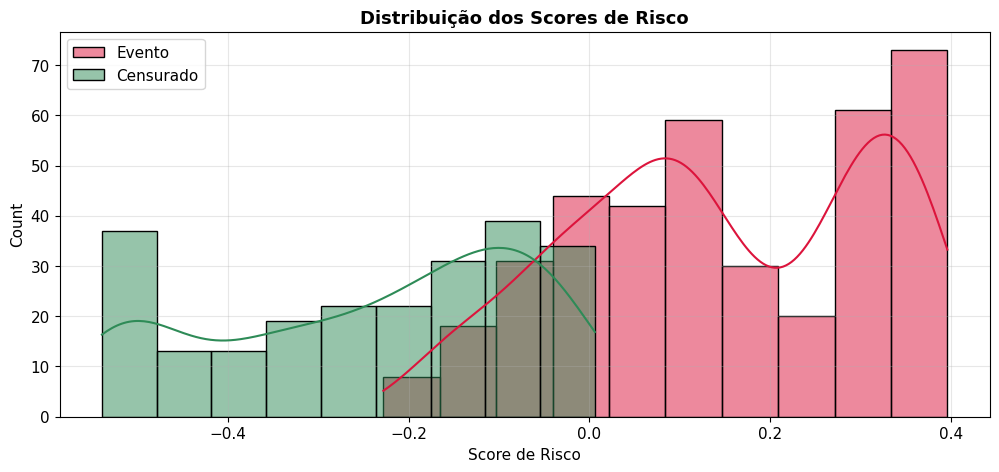

In [30]:
risk_scores = gbs.predict(X_test_s)
c_idx, concordant, discordant, _, _ = concordance_index_censored(y_test['evento'], y_test['duracao'], risk_scores)
print(f'C-Index: {c_idx:.4f} | Concordantes: {concordant} | Discordantes: {discordant}')

plt.figure(figsize=(12,5))
sns.histplot(risk_scores[y_test['evento']], kde=True, color='crimson', alpha=0.5, label='Evento')
sns.histplot(risk_scores[~y_test['evento']], kde=True, color='seagreen', alpha=0.5, label='Censurado')
plt.title('Distribuição dos Scores de Risco', fontsize=13, fontweight='bold')
plt.xlabel('Score de Risco')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 9. Feature Importance

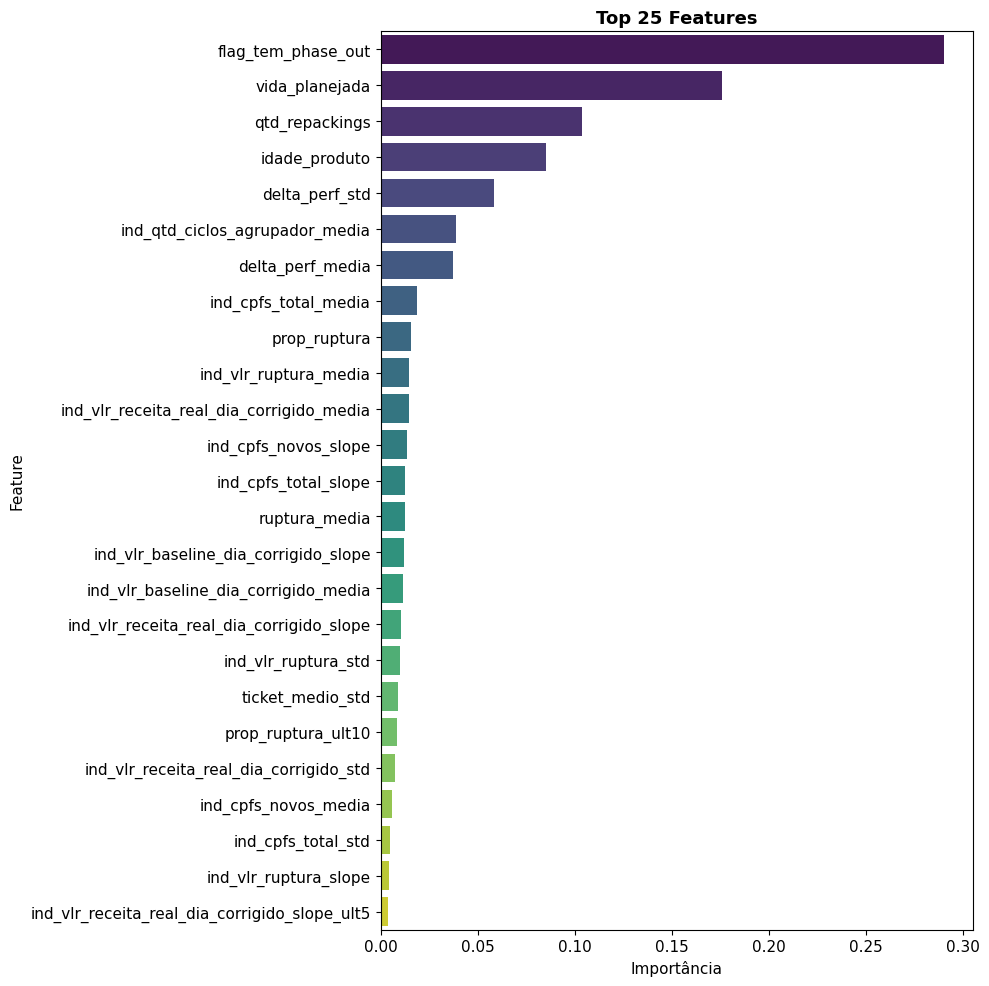

                                 Feature  Importância
                      flag_tem_phase_out     0.290399
                          vida_planejada     0.175994
                          qtd_repackings     0.103469
                           idade_produto     0.085290
                          delta_perf_std     0.058397
          ind_qtd_ciclos_agrupador_media     0.038583
                        delta_perf_media     0.037377
                    ind_cpfs_total_media     0.018708
                            prop_ruptura     0.015585
                   ind_vlr_ruptura_media     0.014701
ind_vlr_receita_real_dia_corrigido_media     0.014395
                    ind_cpfs_novos_slope     0.013370
                    ind_cpfs_total_slope     0.012474
                           ruptura_media     0.012431
    ind_vlr_baseline_dia_corrigido_slope     0.011941
    ind_vlr_baseline_dia_corrigido_media     0.011576
ind_vlr_receita_real_dia_corrigido_slope     0.010712
                     ind_vlr

In [31]:
imp = pd.DataFrame({'Feature': feature_cols, 'Importância': gbs.feature_importances_}).sort_values('Importância', ascending=False)
plt.figure(figsize=(10, 10))
sns.barplot(data=imp.head(25), x='Importância', y='Feature', palette='viridis')
plt.title('Top 25 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(imp.head(20).to_string(index=False))

---
## 10. Kaplan-Meier

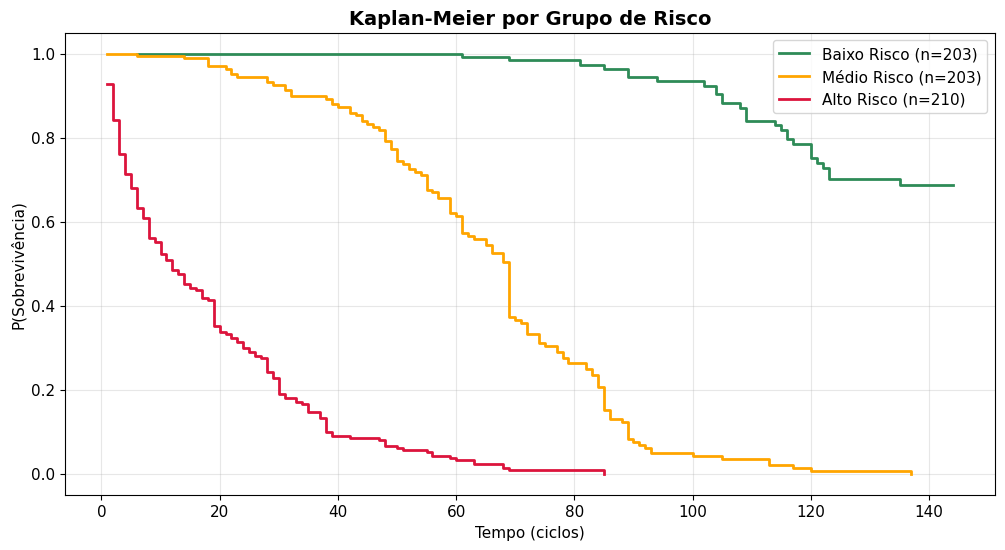

In [32]:
tercis = np.percentile(risk_scores, [33, 66])
grupos = np.digitize(risk_scores, tercis)
plt.figure(figsize=(12, 6))
for g, (label, cor) in enumerate(zip(['Baixo','Médio','Alto'],['seagreen','orange','crimson'])):
    mask = grupos == g
    if mask.sum() > 0:
        t, s = kaplan_meier_estimator(y_test['evento'][mask], y_test['duracao'][mask])
        plt.step(t, s, where='post', lw=2, color=cor, label=f'{label} Risco (n={mask.sum()})')
plt.title('Kaplan-Meier por Grupo de Risco', fontsize=14, fontweight='bold')
plt.xlabel('Tempo (ciclos)')
plt.ylabel('P(Sobrevivência)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 11. Previsão Condicional (Próx. 25 Ciclos)

In [33]:
# ============================================================
# PREVISÃO CONDICIONAL: Próximos 25 ciclos A PARTIR DE AGORA
# P(T < t+25 | T > t) = 1 - S(t+25) / S(t)
# ============================================================

df_vivos = df_surv[df_surv['evento'] == False].copy()
print(f'Prevendo para {len(df_vivos)} produtos VIVOS\n')

X_vivos = df_vivos[feature_cols].values
X_vivos_s = scaler.transform(X_vivos)
surv_vivos = gbs.predict_survival_function(X_vivos_s)
risk_vivos = gbs.predict(X_vivos_s)

prob_proximos_25 = []
ciclo_declinio_list = []

for i, fn in enumerate(surv_vivos):
    t_atual = df_vivos.iloc[i]['duracao']
    t_futuro = t_atual + HORIZONTE
    s_atual = fn(min(t_atual, fn.x.max()))
    s_futuro = fn(min(t_futuro, fn.x.max()))
    prob_cond = np.clip(1 - (s_futuro / s_atual), 0, 1) if s_atual > 0 else 1.0
    prob_proximos_25.append(prob_cond)

    ciclo_decl = np.nan
    for delta in range(1, HORIZONTE + 1):
        t_check = t_atual + delta
        if t_check <= fn.x.max():
            s_check = fn(t_check)
            if s_atual > 0 and (1 - s_check/s_atual) >= 0.5:
                ciclo_decl = delta
                break
    ciclo_declinio_list.append(ciclo_decl)

df_vivos['risk_score'] = risk_vivos
df_vivos['prob_declinio_proximos_25'] = prob_proximos_25
df_vivos['ciclo_declinio_previsto'] = ciclo_declinio_list
df_vivos['previsao_declina'] = (df_vivos['prob_declinio_proximos_25'] > 0.5).astype(int)

print('='*60)
print('PREVISÃO: PRÓXIMOS 25 CICLOS (prob condicional)')
print('='*60)
print(f'\nCom previsão de declínio (>50%): {df_vivos["previsao_declina"].sum()}')
print(f'Sem previsão: {(1-df_vivos["previsao_declina"]).sum()}')
print(f'\nDistribuição da probabilidade:')
print(df_vivos['prob_declinio_proximos_25'].describe())

declina = df_vivos[df_vivos['previsao_declina']==1]
if len(declina)>0:
    print(f'\nCiclo médio de declínio: {declina["ciclo_declinio_previsto"].mean():.1f}')
    print(f'Ciclo mediano: {declina["ciclo_declinio_previsto"].median():.1f}')

Prevendo para 918 produtos VIVOS

PREVISÃO: PRÓXIMOS 25 CICLOS (prob condicional)

Com previsão de declínio (>50%): 0
Sem previsão: 918

Distribuição da probabilidade:
count    918.000000
mean       0.196497
std        0.110124
min        0.000000
25%        0.104749
50%        0.230469
75%        0.266805
max        0.378057
Name: prob_declinio_proximos_25, dtype: float64


---
## 12. Visualizações

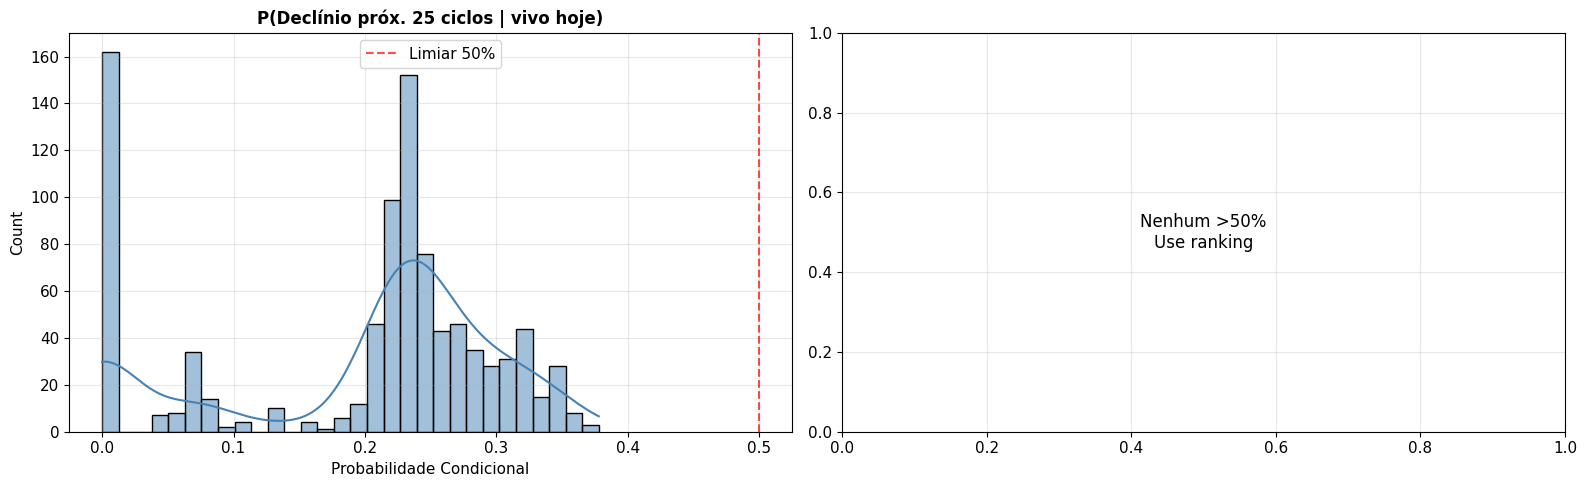

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df_vivos['prob_declinio_proximos_25'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(0.5, ls='--', color='red', alpha=0.7, label='Limiar 50%')
axes[0].set_title('P(Declínio próx. 25 ciclos | vivo hoje)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Probabilidade Condicional')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

ciclos_v = df_vivos['ciclo_declinio_previsto'].dropna()
if len(ciclos_v) > 0:
    sns.histplot(ciclos_v, bins=25, kde=True, color='crimson', ax=axes[1])
    axes[1].set_title('Em QUAL ciclo (1-25)?', fontsize=12, fontweight='bold')
else:
    axes[1].text(0.5,0.5,'Nenhum >50%\nUse ranking',ha='center',va='center',fontsize=12)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 13. Top Risco

In [ ]:
print('--- Top 20 Produtos com MAIOR risco ---')
top = df_vivos.sort_values('prob_declinio_proximos_25', ascending=False).head(20)
display(top[['sk_produto_case','duracao','prob_declinio_proximos_25','ciclo_declinio_previsto','risk_score']])

---
## 14. Resumo

In [ ]:
print('='*60)
print('  RESUMO FINAL - GBS v2 (Features Otimizadas)')
print('='*60)
print(f'\n  Modelo: Gradient Boosting Survival')
print(f'  Horizonte: {HORIZONTE} ciclos (a partir de agora)')
print(f'  Previsão: P(T<t+25 | T>t) = 1 - S(t+25)/S(t)')
print(f'  Features: {len(feature_cols)}')
print(f'  C-Index Treino: {c_train:.4f}')
print(f'  C-Index Teste:  {c_test:.4f}')
print(f'  Em risco (>50%): {df_vivos["previsao_declina"].sum()}/{len(df_vivos)}')
print('='*60)